Chapter 27
# 主成分分析
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as pdr
# pip install pandas_datareader
import seaborn as sns
import statsmodels.multivariate.pca as pca
#导入读取鸢尾花数据函数
from sklearn.datasets import load_iris

In [97]:
iris = load_iris()
X = iris.data

In [99]:
#将数据拼接成50*12
new_X = np.hstack([
    X[0:50,:],
    X[50:100,:],
    X[100:150,:]])

In [105]:
#转换为df
new_X_df = pd.DataFrame(new_X)

In [109]:
#更换数据名称
new_X_df.columns = [
    '1_sepal_length', '1_sepal_width', '1_petal_length', '1_petal_width',
    '2_sepal_length', '2_sepal_width', '2_petal_length', '2_petal_width',
    '3_sepal_length', '3_sepal_width', '4_petal_length', '4_petal_width'
]

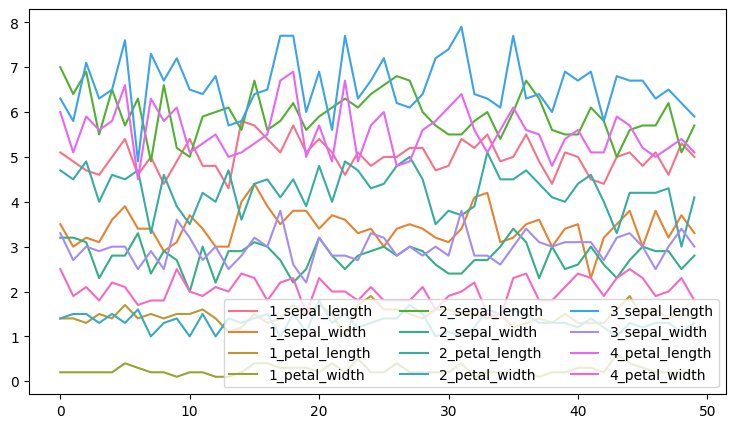

In [113]:
# 绘制走势
fig, ax = plt.subplots(figsize = (9,5))
sns.lineplot(new_X_df,markers=False,dashes=False,
             palette = "husl",ax = ax)
ax.legend(loc='lower right',ncol=3)

In [115]:
# 绘制走势波动
X_df = new_X_df.pct_change()
X_df = X_df.dropna()

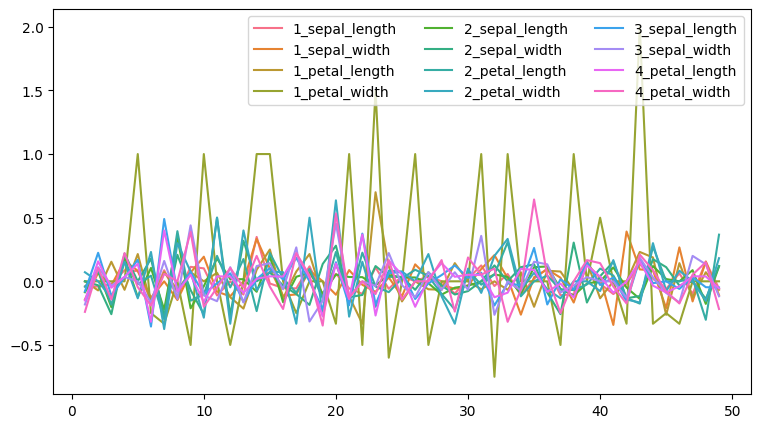

In [119]:
# 可视化收益率
fig, ax = plt.subplots(figsize = (9,5))
sns.lineplot(X_df,markers=False, 
             dashes=False,palette = "husl",ax = ax)
ax.legend(loc='upper right',ncol=3)

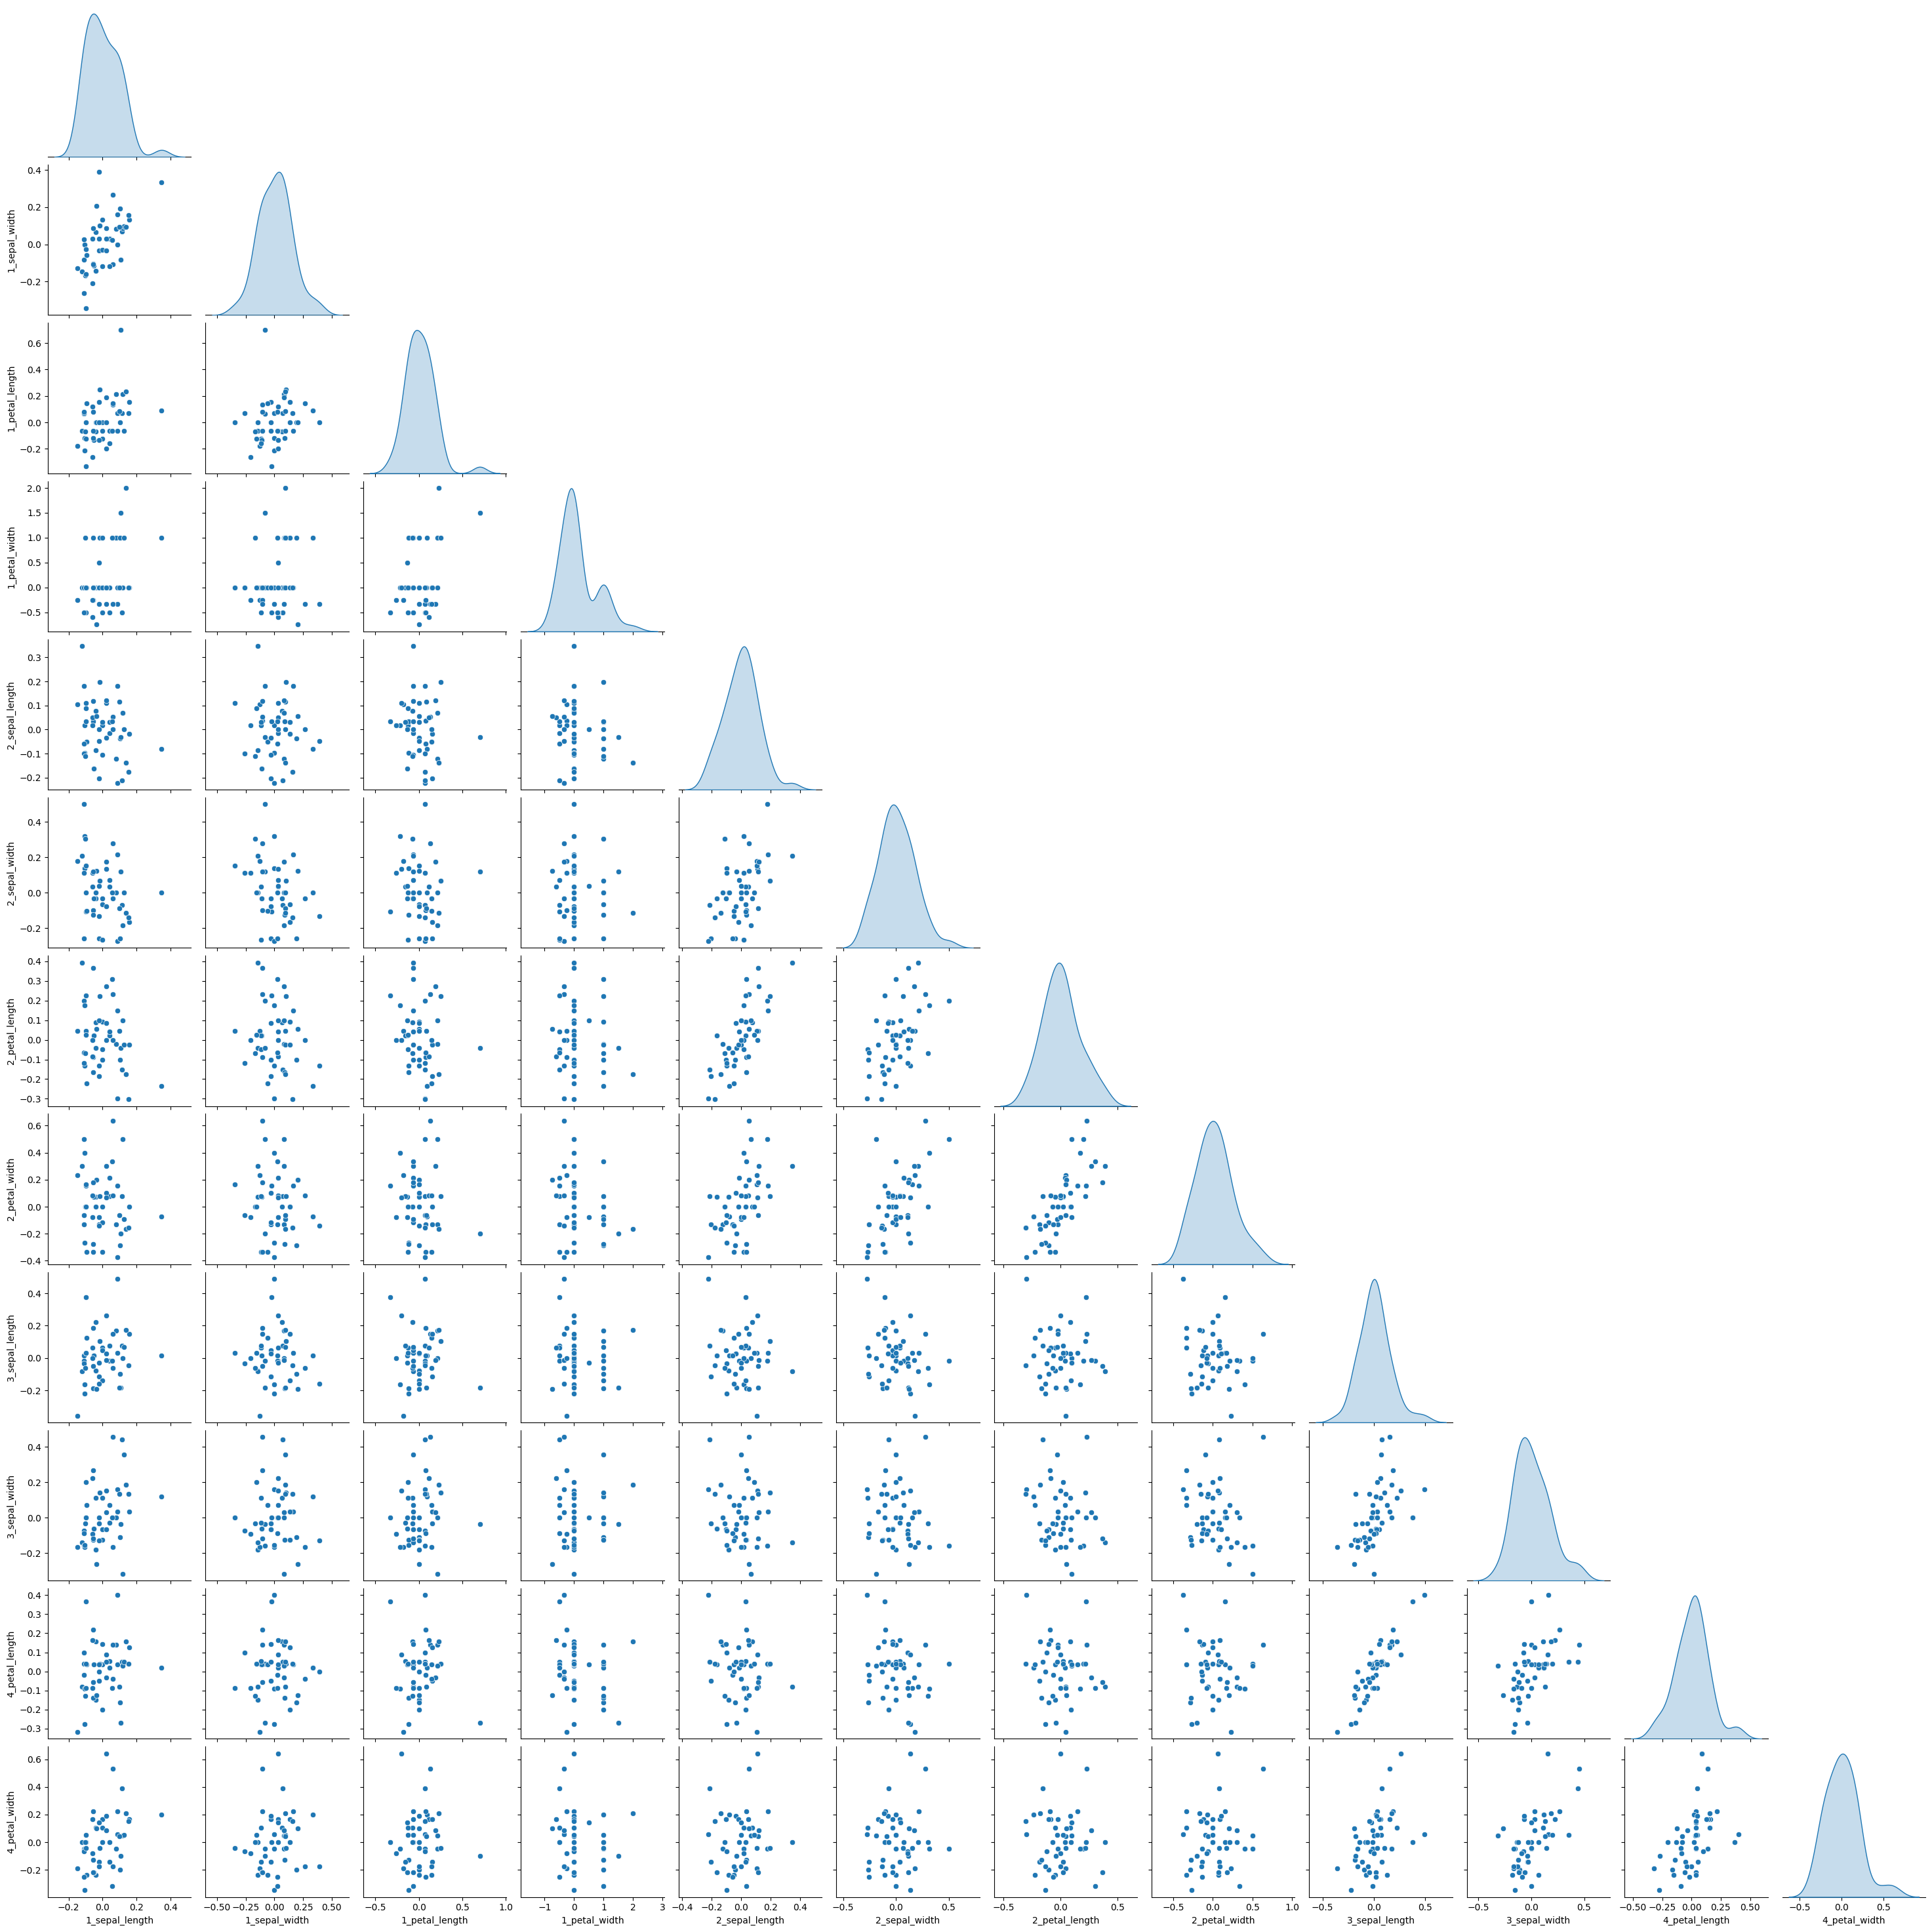

In [121]:
# 成对特征散点图
sns.pairplot(X_df, corner=True, diag_kind="kde")

In [123]:
# 相关性系数矩阵
C = X_df.corr()

<Axes: >

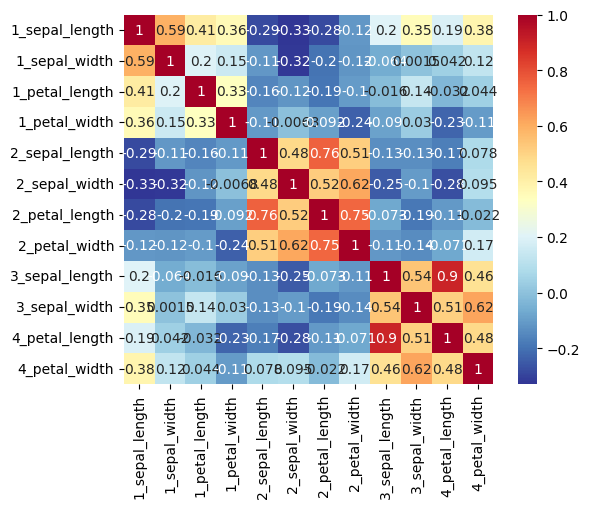

In [125]:
fig, ax = plt.subplots()
sns.heatmap(C, ax = ax, 
            annot=True,
            cmap = 'RdYlBu_r', 
            square = True)

In [146]:
# 主成分分析
pca_model = pca.PCA(X_df, standardize=True)

In [148]:
variance_V = pca_model.eigenvals 
# 计算主成分的方差解释比例

In [150]:
explained_var_ratio = variance_V / variance_V.sum()

In [152]:
PC_range = np.arange(len(variance_V)) + 1

In [154]:
labels = ['$PC_' + str(index) + '$' for index in PC_range]

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/f0/8_68v87s7qg9dj06g39mn0gh0000gn/T/ipykernel_40557/3285663740.py:6: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_ylabel('Eigen value $\lambda$ (PC variance)', color='b')


(0.9, 12.1)

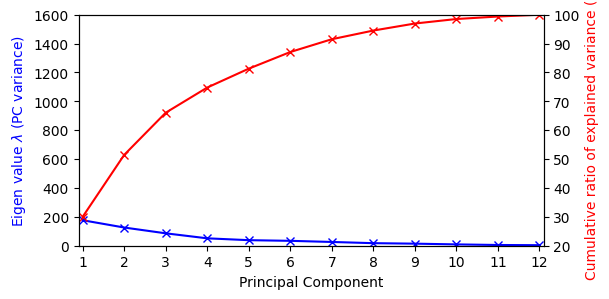

In [137]:
# 陡坡图
fig, ax1 = plt.subplots(figsize = (6,3))

ax1.plot(PC_range, variance_V, 'b', marker = 'x')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Eigen value $\lambda$ (PC variance)', color='b')
ax1.set_ylim(0,1600); ax1.set_xticks(PC_range)

ax2 = ax1.twinx()
ax2.plot(PC_range, np.cumsum(explained_var_ratio)*100, 
         'r', marker = 'x')
ax2.set_ylabel('Cumulative ratio of explained variance (%)',
               color='r')
ax2.set_ylim(20,100)
ax2.set_xlim(PC_range.min() - 0.1,PC_range.max() + 0.1)

In [159]:
print(pca_model.loadings.columns)#超过10个需要检查命名

Index(['comp_00', 'comp_01', 'comp_02', 'comp_03', 'comp_04', 'comp_05',
       'comp_06', 'comp_07', 'comp_08', 'comp_09', 'comp_10', 'comp_11'],
      dtype='object')


In [161]:
# PCA载荷
loadings= pca_model.loadings[['comp_00','comp_01','comp_02']]

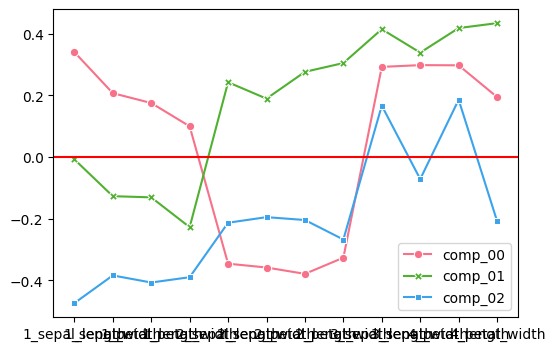

In [163]:
fig, ax = plt.subplots(figsize = (6,4))
sns.lineplot(data=loadings,
             markers=True, dashes=False, palette = "husl")
plt.axhline(y=0, color='r', linestyle='-')

In [165]:
# 用前3主成分获得还原数据
X_df_ = pca_model.project(3)

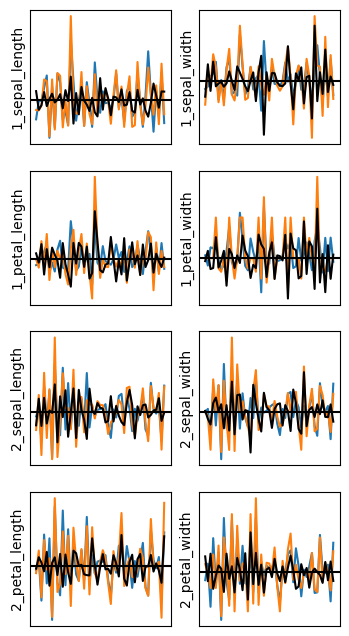

In [167]:
# 比较原始数据和还原数据
# 线图
fig, axes = plt.subplots(4,2,figsize=(4,8))
axes = axes.flatten()

for col_idx, ax_idx in zip(list(X_df_.columns),axes):
    sns.lineplot(X_df_[col_idx],ax = ax_idx)
    sns.lineplot(X_df[col_idx],ax = ax_idx) 
    sns.lineplot(X_df[col_idx] - X_df_[col_idx], 
                 c = 'k', ax = ax_idx) 
    ax_idx.set_xticks([]); ax_idx.set_yticks([])
    ax_idx.axhline(y = 0, c = 'k')

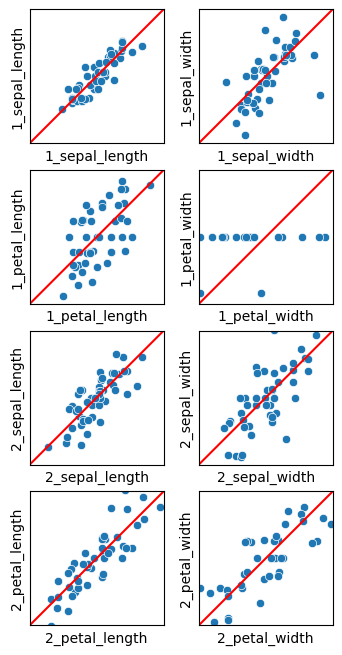

In [169]:
# 散点图
fig, axes = plt.subplots(4,2,figsize=(4,8))
axes = axes.flatten()

for col_idx, ax_idx in zip(list(X_df_.columns),axes):
    sns.scatterplot(x = X_df_[col_idx],
                    y = X_df[col_idx], 
                    ax = ax_idx)
    ax_idx.plot([-0.3, 0.3],[-0.3, 0.3],c = 'r')
    ax_idx.set_aspect('equal', adjustable='box')
    ax_idx.set_xticks([]); ax_idx.set_yticks([])
    ax_idx.set_xlim(-0.3, 0.3); ax_idx.set_ylim(-0.3, 0.3)